In [52]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

In [53]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Find the folder that contains train.csv and test.csv
ROOT = None
for d, _, fs in os.walk("/kaggle/input"):
    if "train.csv" in fs and "test.csv" in fs:
        ROOT = d
        break
print("ROOT:", ROOT)

# Load the CSVs
train_df = pd.read_csv(f"{ROOT}/train.csv")
test_df  = pd.read_csv(f"{ROOT}/test.csv")
sub_df   = pd.read_csv(f"{ROOT}/sample_submission.csv")

print("\nShapes -> train:", train_df.shape, "| test:", test_df.shape, "| sample_sub:", sub_df.shape)
print("\nTrain columns:", list(train_df.columns))
print("Test columns :", list(test_df.columns))
print("Sub columns  :", list(sub_df.columns))

print("\n--- train head ---");  display(train_df.head())
print("--- test head ---");    display(test_df.head())
print("--- sample submission head ---"); display(sub_df.head())

print("\nMissing values (train):\n", train_df.isna().sum())
print("Duplicate filenames in train:", train_df.iloc[:, 0].duplicated().sum())

ROOT: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

Shapes -> train: (769, 2) | test: (216, 2) | sample_sub: (204, 2)

Train columns: ['filename', 'label']
Test columns : ['filename', 'label']
Sub columns  : ['filename', 'label']

--- train head ---


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0


--- test head ---


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1


--- sample submission head ---


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1



Missing values (train):
 filename    0
label       0
dtype: int64
Duplicate filenames in train: 0


Total .wav files found: 773
Train files missing on disk: 0
Test files missing on disk : 0

Sample rates: {16000: 769}
Channels    : {1: 769}
count    769.000000
mean      55.781067
std        7.908964
min       20.060000
25%       54.186687
50%       60.074688
75%       60.074688
max       61.040000
Name: duration, dtype: float64

Label stats:
 count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64

Label value counts:
 label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64
Baseline RMSE (always predict the mean): 1.2382


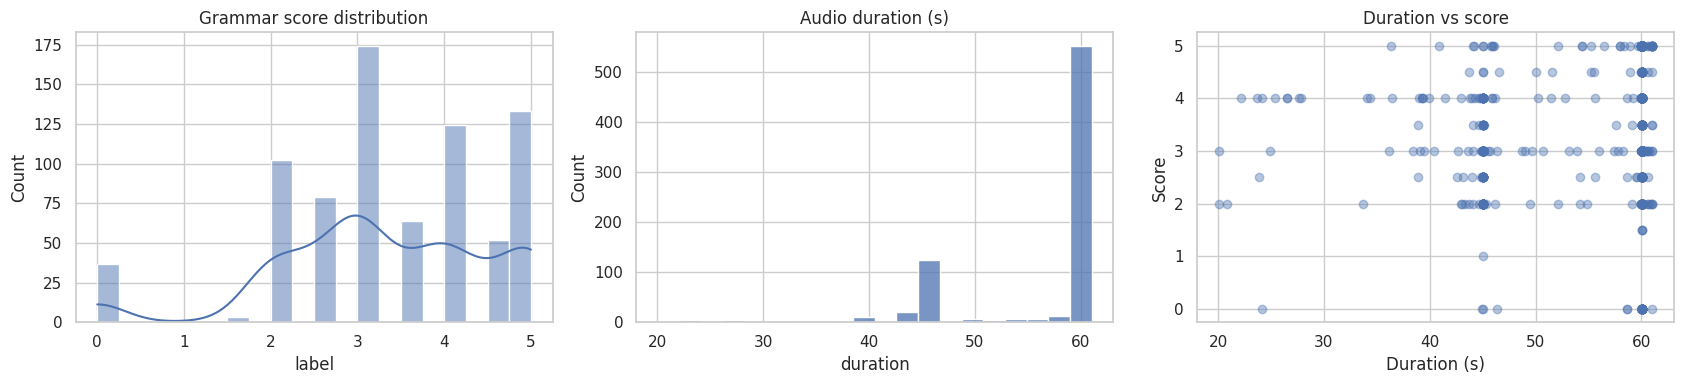

In [54]:
import soundfile as sf

FILE_COL  = train_df.columns[0]    # change if the filename column is different
LABEL_COL = train_df.columns[-1]   # change if the label column is different

# Map every .wav file name to its full path
audio_map = {os.path.basename(p): p for p in glob.glob(f"{ROOT}/**/*.wav", recursive=True)}
print("Total .wav files found:", len(audio_map))

def fname(x):
    x = str(x)
    return x if x.lower().endswith(".wav") else x + ".wav"

train_df["fname"] = train_df[FILE_COL].map(fname)
test_df["fname"]  = test_df[FILE_COL].map(fname)
print("Train files missing on disk:", (~train_df.fname.isin(audio_map)).sum())
print("Test files missing on disk :", (~test_df.fname.isin(audio_map)).sum())

# Audio properties (duration, sample rate, channels)
def audio_info(fn):
    i = sf.info(audio_map[fn])
    return i.duration, i.samplerate, i.channels

info = [audio_info(f) for f in train_df.fname]
train_df["duration"], train_df["sr"], train_df["channels"] = zip(*info)
print("\nSample rates:", train_df.sr.value_counts().to_dict())
print("Channels    :", train_df.channels.value_counts().to_dict())
print(train_df.duration.describe())

# Label analysis
y = train_df[LABEL_COL].astype(float)
print("\nLabel stats:\n", y.describe())
print("\nLabel value counts:\n", y.value_counts().sort_index())
print("Baseline RMSE (always predict the mean):", np.sqrt(((y - y.mean())**2).mean()).round(4))

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(y, bins=20, kde=True, ax=ax[0]);  ax[0].set_title("Grammar score distribution")
sns.histplot(train_df.duration, bins=20, ax=ax[1]); ax[1].set_title("Audio duration (s)")
ax[2].scatter(train_df.duration, y, alpha=.4); ax[2].set(xlabel="Duration (s)", ylabel="Score", title="Duration vs score")
plt.tight_layout(); plt.show()

In [55]:
# --- A) Are there files with the same name in different folders? ---
all_wavs = glob.glob(f"{ROOT}/**/*.wav", recursive=True)
wav_df = pd.DataFrame({"path": all_wavs})
wav_df["name"]   = wav_df.path.map(os.path.basename)
wav_df["folder"] = wav_df.path.map(lambda p: os.path.relpath(os.path.dirname(p), ROOT))

print("Total wav paths on disk:", len(wav_df))
print("Unique names           :", wav_df.name.nunique())
print("Files per folder:\n", wav_df.folder.value_counts())
print("Names appearing in more than one folder:", (wav_df.groupby("name").folder.nunique() > 1).sum())

# --- B) Which folder does each csv row actually live in? ---
folders_of = wav_df.groupby("name").folder.apply(list)
print("\nTrain files found in:", train_df.filename.map(lambda f: tuple(folders_of.get(f, []))).value_counts().to_dict())
print("Test  files found in:", test_df.filename.map(lambda f: tuple(folders_of.get(f, []))).value_counts().to_dict())

# --- C) Test vs sample_submission ---
t, s = set(test_df.filename), set(sub_df.filename)
print("\nTest:", len(t), "| Sample sub:", len(s), "| in both:", len(t & s),
      "| only in test:", len(t - s), "| only in sample_sub:", len(s - t))
print("Train/test name overlap:", len(set(train_df.filename) & t))

# --- D) The zero-score clips ---
zero = train_df[train_df.label == 0]
print("\nDuration of label=0 clips:\n", zero.duration.describe().round(2))
print("Duration of label>0 clips:\n", train_df[train_df.label > 0].duration.describe().round(2))
print("First label=0 files:", zero.filename.head(5).tolist())


Total wav paths on disk: 985
Unique names           : 773
Files per folder:
 folder
train    769
test     216
Name: count, dtype: int64
Names appearing in more than one folder: 212

Train files found in: {('train',): 557, ('test', 'train'): 212}
Test  files found in: {('test', 'train'): 212, ('test',): 4}

Test: 216 | Sample sub: 204 | in both: 25 | only in test: 191 | only in sample_sub: 179
Train/test name overlap: 212

Duration of label=0 clips:
 count    37.00
mean     57.86
std       6.99
min      24.13
25%      60.07
50%      60.07
75%      60.07
max      61.03
Name: duration, dtype: float64
Duration of label>0 clips:
 count    732.00
mean      55.68
std        7.94
min       20.06
25%       51.96
50%       60.07
75%       60.07
max       61.04
Name: duration, dtype: float64
First label=0 files: ['audio_5055.wav', 'audio_5066.wav', 'audio_5069.wav', 'audio_5073.wav', 'audio_5039.wav']


In [56]:
import hashlib
from scipy.stats import spearmanr

# Split-specific lookup, used from now on instead of audio_map
train_path = {os.path.basename(p): p for p in all_wavs if os.sep + "train" + os.sep in p}
test_path  = {os.path.basename(p): p for p in all_wavs if os.sep + "test"  + os.sep in p}
print("train paths:", len(train_path), "| test paths:", len(test_path))

def md5(p):
    with open(p, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# --- A) Compare the two same-named files ---
shared = sorted(set(train_path) & set(test_path))
rows = []
for n in shared:
    a, b = train_path[n], test_path[n]
    rows.append(dict(name=n, same_size=os.path.getsize(a) == os.path.getsize(b),
                     same_md5=md5(a) == md5(b),
                     dur_train=sf.info(a).duration, dur_test=sf.info(b).duration))
cmp_df = pd.DataFrame(rows)
print("\nShared names:", len(cmp_df))
print("Identical size:", cmp_df.same_size.sum(), "| Identical bytes (md5):", cmp_df.same_md5.sum())
print("Max duration difference (s):", (cmp_df.dur_train - cmp_df.dur_test).abs().max())

# --- B) Do all train files read from train/ now, and what is the real duration summary? ---
train_df["path"] = train_df.filename.map(train_path)
test_df["path"]  = test_df.filename.map(test_path)
print("\nMissing paths -> train:", train_df.path.isna().sum(), "| test:", test_df.path.isna().sum())
train_df["duration"] = [sf.info(p).duration for p in train_df.path]
print(train_df.duration.describe().round(2))

# --- C) Does the file number relate to the label? ---
train_df["file_no"] = train_df.filename.str.extract(r"(\d+)").astype(int)
print("\nSpearman(file number, label):", round(spearmanr(train_df.file_no, train_df.label)[0], 3))
print(train_df.groupby("label").file_no.agg(["count", "min", "median", "max"]))



train paths: 769 | test paths: 216

Shared names: 212
Identical size: 25 | Identical bytes (md5): 0
Max duration difference (s): 38.58

Missing paths -> train: 0 | test: 0
count    769.00
mean      55.78
std        7.91
min       20.06
25%       54.19
50%       60.07
75%       60.07
max       61.04
Name: duration, dtype: float64

Spearman(file number, label): 0.024
       count   min  median   max
label                           
0.0       37  5037  5055.0  5073
1.0        1   108   108.0   108
1.5        3    65   580.0   581
2.0      102     8   347.0   731
2.5       79     2   468.0   748
3.0      174     0   426.5   774
3.5       64     1   318.5   737
4.0      124     9   378.0   783
4.5       52    12   405.5   784
5.0      133    91   371.0   782


In [57]:
import os, glob, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import soundfile as sf, torch
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEV, "|", torch.cuda.get_device_name(0) if DEV == "cuda" else "NO GPU - fix before continuing")

ROOT = next(d for d, _, fs in os.walk("/kaggle/input") if "train.csv" in fs and "test.csv" in fs)
train_df = pd.read_csv(f"{ROOT}/train.csv")
test_df  = pd.read_csv(f"{ROOT}/test.csv")
sub_df   = pd.read_csv(f"{ROOT}/sample_submission.csv")

all_wavs   = glob.glob(f"{ROOT}/**/*.wav", recursive=True)
train_path = {os.path.basename(p): p for p in all_wavs if os.path.basename(os.path.dirname(p)) == "train"}
test_path  = {os.path.basename(p): p for p in all_wavs if os.path.basename(os.path.dirname(p)) == "test"}
train_df["path"] = train_df.filename.map(train_path)
test_df["path"]  = test_df.filename.map(test_path)
train_df["file_no"] = train_df.filename.str.extract(r"(\d+)").astype(int)
test_df["file_no"]  = test_df.filename.str.extract(r"(\d+)").astype(int)

print("Missing paths -> train:", train_df.path.isna().sum(), "| test:", test_df.path.isna().sum())
print("Test file numbers: min", test_df.file_no.min(), "| max", test_df.file_no.max())
print("Test files in the 5037-5073 range (the label-0 batch):", test_df.file_no.between(5037, 5073).sum())

Device: cuda | Tesla T4
Missing paths -> train: 0 | test: 0
Test file numbers: min 0 | max 215
Test files in the 5037-5073 range (the label-0 batch): 0


In [58]:
from faster_whisper import WhisperModel

if "asr" not in globals():          # don't reload the model if it's already in memory
    asr = WhisperModel("large-v3", device=DEV, compute_type="float16")

def load_audio(path):
    audio, sr = sf.read(path, dtype="float32")
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    assert sr == 16000, f"unexpected sample rate {sr}"
    return audio

def transcribe_one(path, language=None):
    segs, info = asr.transcribe(load_audio(path), language=language, beam_size=5,
                                word_timestamps=True, condition_on_previous_text=False,
                                vad_filter=False)
    words = [[w.word.strip(), float(w.start), float(w.end), float(w.probability)]
             for s in segs for w in (s.words or [])]
    return {"words": words, "duration": float(info.duration),
            "language": info.language, "lang_prob": float(info.language_probability)}

# Smoke test: 2 clips labelled 0 + 3 random others
sample = pd.concat([train_df[train_df.label == 0].sample(2, random_state=1),
                    train_df[train_df.label > 0].sample(3, random_state=1)])
for _, r in sample.iterrows():
    t0 = time.time()
    out = transcribe_one(r.path)
    text = " ".join(w[0] for w in out["words"])
    p = np.mean([w[3] for w in out["words"]]) if out["words"] else 0
    print(f"\n{r.filename} | label={r.label} | lang={out['language']} ({out['lang_prob']:.2f}) | "
          f"{len(out['words'])} words | mean word prob={p:.2f} | {time.time()-t0:.1f}s")
    print(text[:500])


audio_5069.wav | label=0.0 | lang=nn (0.59) | 4 words | mean word prob=0.89 | 14.9s
Teksting av Nicolai Winther

audio_5060.wav | label=0.0 | lang=en (0.53) | 120 words | mean word prob=0.63 | 3.8s
My special hobby. My favorite hobby is watching TV whenever I am healthy. I love watching television. It is a very attractive new hobby. Hobby helps us to expand our knowledge and to change our priorities. First, I like to change all my food kind of and then I start watching TV. The variation in meaning and parts of the expression inside me has increased my ability to approach the world. So always watching different useful stuff and meaning enters in front of my mind or for them until it's lost 

audio_515.wav | label=2.5 | lang=en (0.98) | 110 words | mean word prob=0.83 | 3.6s
My goal was to become a software user. This is my lifetime goal because this makes me inspired by Sudha Murthy. She is the founder of Gameforces. She makes me very inspired by her way of teaching and how to deal wit

In [59]:
def detect_lang(path):
    out = asr.detect_language(load_audio(path))        # (language, prob, all_probs)
    lang, prob = out[0], out[1]
    p_en = dict(out[2]).get("en", 0.0) if len(out) > 2 else np.nan
    return lang, prob, p_en

# warm-up so the first timing isn't distorted
_ = transcribe_one(sample.path.iloc[2], language="en")

for _, r in sample.iterrows():
    t0 = time.time()
    lang, prob, p_en = detect_lang(r.path)
    out = transcribe_one(r.path, language="en")
    text = " ".join(w[0] for w in out["words"])
    p = np.mean([w[3] for w in out["words"]]) if out["words"] else 0
    print(f"\n{r.filename} | label={r.label} | detected={lang} ({prob:.2f}) | P(en)={p_en:.2f} | "
          f"{len(out['words'])} words | mean word prob={p:.2f} | {time.time()-t0:.1f}s")
    print(text[:400])


audio_5069.wav | label=0.0 | detected=nn (0.59) | P(en)=0.12 | 3 words | mean word prob=0.64 | 13.8s
Thanks for watching!

audio_5060.wav | label=0.0 | detected=en (0.53) | P(en)=0.53 | 120 words | mean word prob=0.63 | 3.9s
My special hobby. My favorite hobby is watching TV whenever I am healthy. I love watching television. It is a very attractive new hobby. Hobby helps us to expand our knowledge and to change our priorities. First, I like to change all my food kind of and then I start watching TV. The variation in meaning and parts of the expression inside me has increased my ability to approach the world. So always

audio_515.wav | label=2.5 | detected=en (0.98) | P(en)=0.98 | 110 words | mean word prob=0.83 | 3.6s
My goal was to become a software user. This is my lifetime goal because this makes me inspired by Sudha Murthy. She is the founder of Gameforces. She makes me very inspired by her way of teaching and how to deal with families and along with the colleagues and yeah this i

In [60]:
from tqdm.auto import tqdm

def transcribe_one(path):
    audio = load_audio(path)
    det = asr.detect_language(audio)                       # (lang, prob, all_probs)
    p_en = dict(det[2]).get("en", 0.0)
    segs, info = asr.transcribe(audio, language="en", beam_size=5, word_timestamps=True,
                                condition_on_previous_text=False, vad_filter=False)
    words, seg_stats = [], []
    for s in segs:
        seg_stats.append([float(s.avg_logprob), float(s.no_speech_prob), float(s.compression_ratio)])
        for w in (s.words or []):
            words.append([w.word.strip(), float(w.start), float(w.end), float(w.probability)])
    return {"words": words, "seg_stats": seg_stats, "duration": float(info.duration),
            "det_lang": det[0], "det_prob": float(det[1]), "p_en": float(p_en)}

def run_asr(df, cache_path):
    res = json.load(open(cache_path)) if os.path.exists(cache_path) else {}
    todo = [(fn, p) for fn, p in zip(df.filename, df.path) if fn not in res]
    print(f"{cache_path}: {len(res)} cached, {len(todo)} to do")
    for i, (fn, p) in enumerate(tqdm(todo)):
        res[fn] = transcribe_one(p)
        if i % 25 == 0:
            json.dump(res, open(cache_path, "w"))
    json.dump(res, open(cache_path, "w"))
    return res

asr_train = run_asr(train_df, "/kaggle/working/asr_train.json")
asr_test  = run_asr(test_df,  "/kaggle/working/asr_test.json")
print("Done:", len(asr_train), len(asr_test))

/kaggle/working/asr_train.json: 376 cached, 393 to do


  0%|          | 0/393 [00:00<?, ?it/s]

/kaggle/working/asr_test.json: 0 cached, 216 to do


  0%|          | 0/216 [00:00<?, ?it/s]

Done: 769 216


(769, 33) (216, 33)


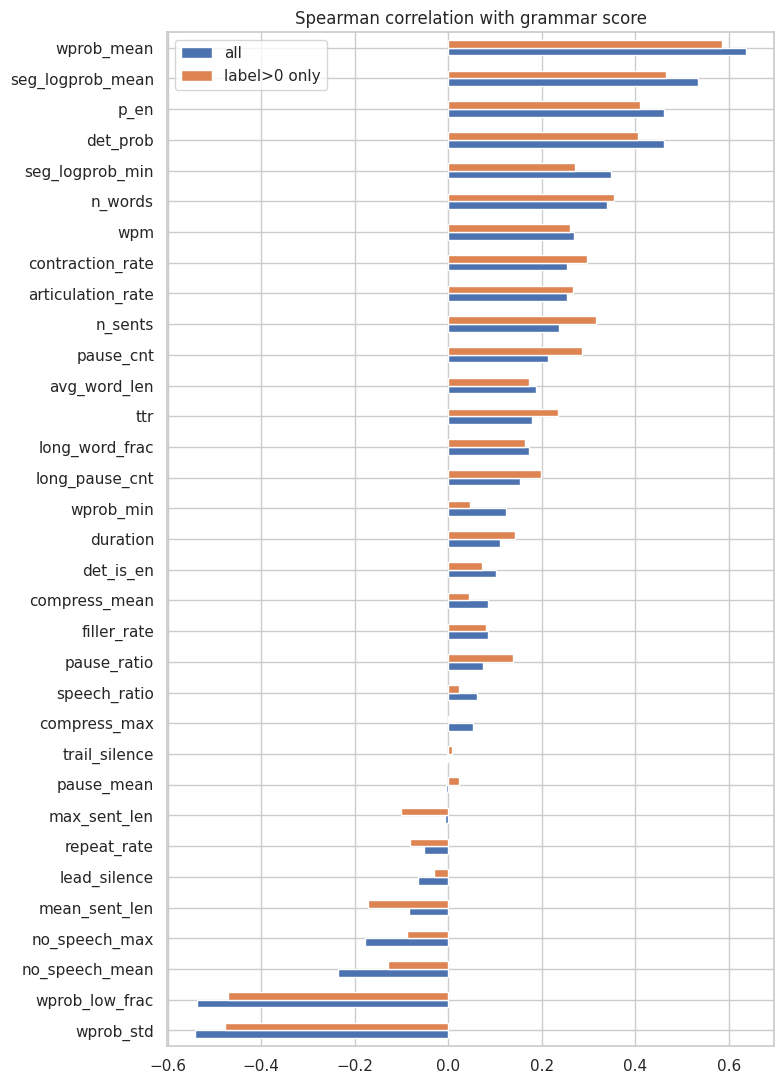

,all,label>0 only
n_sents,0.237,0.316
articulation_rate,0.253,0.267
contraction_rate,0.254,0.296
wpm,0.268,0.260
n_words,0.339,0.355
seg_logprob_min,0.348,0.270
det_prob,0.461,0.407
p_en,0.462,0.410
seg_logprob_mean,0.535,0.466
wprob_mean,0.638,0.586


,all,label>0 only
wprob_std,-0.542,-0.478
wprob_low_frac,-0.538,-0.470
no_speech_mean,-0.235,-0.128
no_speech_max,-0.179,-0.088
mean_sent_len,-0.085,-0.173
lead_silence,-0.066,-0.031
repeat_rate,-0.052,-0.082
max_sent_len,-0.007,-0.101
pause_mean,-0.004,0.023
trail_silence,-0.002,0.009


In [61]:
import re
from scipy.stats import spearmanr
FILLERS = {"um", "uh", "er", "erm", "ah", "hmm", "mm", "uhm", "eh"}

def make_feats(rec):
    words = rec["words"]; dur = max(rec["duration"], 1e-6)
    toks = [re.sub(r"[^\w']", "", w[0].lower()) for w in words]
    toks = [t for t in toks if t]
    n = len(toks)
    text = " ".join(w[0] for w in words)
    sents = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    f = {}
    # --- transcript statistics ---
    f["n_words"] = n
    f["n_sents"] = len(sents)
    f["mean_sent_len"] = n / max(len(sents), 1)
    f["max_sent_len"] = max([len(s.split()) for s in sents], default=0)
    f["ttr"] = len(set(toks)) / max(n, 1)
    f["avg_word_len"] = np.mean([len(t) for t in toks]) if n else 0
    f["long_word_frac"] = np.mean([len(t) > 7 for t in toks]) if n else 0
    f["filler_rate"] = sum(t in FILLERS for t in toks) / max(n, 1)
    f["repeat_rate"] = sum(toks[i] == toks[i-1] for i in range(1, n)) / max(n, 1)
    f["contraction_rate"] = sum("'" in t for t in toks) / max(n, 1)
    # --- ASR word confidence ---
    p = np.array([w[3] for w in words]) if words else np.array([0.0])
    f["wprob_mean"], f["wprob_min"], f["wprob_std"] = p.mean(), p.min(), p.std()
    f["wprob_low_frac"] = (p < 0.5).mean()
    # --- whisper segment-level and language signals (unscorable-audio detectors) ---
    ss = np.array(rec["seg_stats"]) if rec["seg_stats"] else np.array([[-5.0, 1.0, 0.0]])
    f["seg_logprob_mean"], f["seg_logprob_min"] = ss[:, 0].mean(), ss[:, 0].min()
    f["no_speech_mean"], f["no_speech_max"] = ss[:, 1].mean(), ss[:, 1].max()
    f["compress_mean"], f["compress_max"] = ss[:, 2].mean(), ss[:, 2].max()
    f["p_en"], f["det_prob"], f["det_is_en"] = rec["p_en"], rec["det_prob"], float(rec["det_lang"] == "en")
    # --- timing / fluency ---
    if len(words) > 1:
        st = np.array([w[1] for w in words]); en = np.array([w[2] for w in words])
        gaps = st[1:] - en[:-1]; pauses = gaps[gaps > 0.25]; span = max(en[-1] - st[0], 1e-6)
        f["wpm"] = n / dur * 60
        f["articulation_rate"] = n / span * 60
        f["pause_cnt"] = len(pauses)
        f["pause_mean"] = pauses.mean() if len(pauses) else 0
        f["pause_ratio"] = pauses.sum() / span
        f["long_pause_cnt"] = int((gaps > 0.7).sum())
        f["lead_silence"] = st[0] / dur
        f["trail_silence"] = (dur - en[-1]) / dur
        f["speech_ratio"] = span / dur
    else:
        for k in ["wpm", "articulation_rate", "pause_cnt", "pause_mean", "pause_ratio",
                  "long_pause_cnt", "lead_silence", "trail_silence", "speech_ratio"]:
            f[k] = 0
    f["duration"] = dur
    return text, f

def build(df, asr):
    out = [make_feats(asr[fn]) for fn in df.filename]
    return [t for t, _ in out], pd.DataFrame([f for _, f in out])

train_text, F_train = build(train_df, asr_train)
test_text,  F_test  = build(test_df,  asr_test)
F_train = F_train.replace([np.inf, -np.inf], 0).fillna(0); F_test = F_test.replace([np.inf, -np.inf], 0).fillna(0)
print(F_train.shape, F_test.shape)

# How well does each feature track the score? (Spearman, whole train set and excluding zeros)
ytr = train_df.label.values
nz = ytr > 0
corr = pd.DataFrame({"all": F_train.apply(lambda c: spearmanr(c, ytr)[0]),
                     "label>0 only": F_train[nz].apply(lambda c: spearmanr(c, ytr[nz])[0])}).sort_values("all")
corr.plot.barh(figsize=(8, 11)); plt.title("Spearman correlation with grammar score"); plt.tight_layout(); plt.show()
display(corr.round(3).tail(10)); display(corr.round(3).head(10))

Baseline RMSE (predict mean): 1.2382

Ridge    | CV RMSE 0.7682 | CV Pearson 0.7845 | Train RMSE 0.7240 | RMSE on zeros 1.553 | RMSE on non-zeros 0.706
LightGBM | CV RMSE 0.7423 | CV Pearson 0.8006 | Train RMSE 0.3911 | RMSE on zeros 1.180 | RMSE on non-zeros 0.713


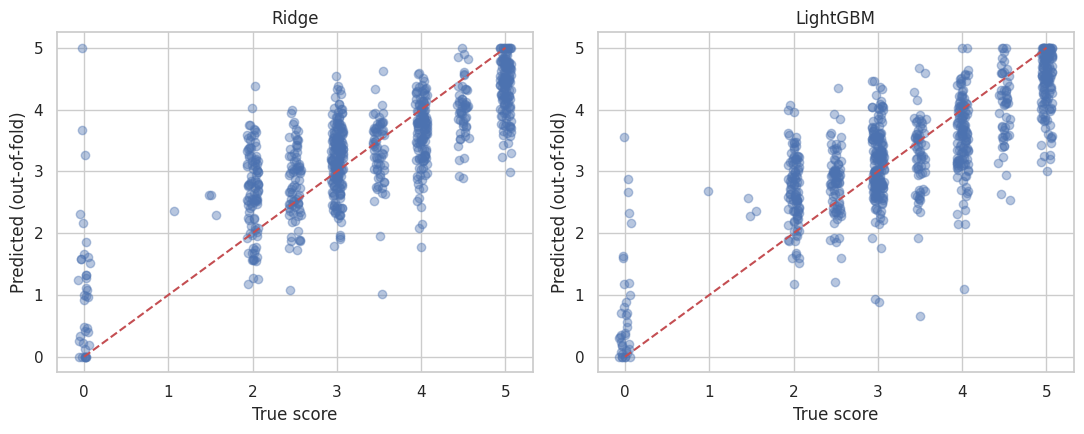

         wprob_mean   p_en  seg_logprob_mean  n_words  no_speech_mean
is_zero                                                              
False         0.922  0.975            -0.210    103.0           0.087
True          0.714  0.637            -0.511     90.0           0.432


In [62]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import lightgbm as lgb

y = train_df.label.values.astype(float)
strat = np.clip(np.round(y), 0, 5).astype(int)
strat[strat == 1] = 2                              # the single "1.0" clip is too rare to stratify on
folds = list(StratifiedKFold(5, shuffle=True, random_state=42).split(np.zeros(len(y)), strat))

def metrics(yt, yp):
    return dict(RMSE=np.sqrt(mean_squared_error(yt, yp)), Pearson=pearsonr(yt, yp)[0])

def cv_run(make, X, y, name):
    oof = np.zeros(len(y))
    for tr, va in folds:
        oof[va] = make().fit(X[tr], y[tr]).predict(X[va])
    oof = np.clip(oof, 0, 5)
    train_pred = np.clip(make().fit(X, y).predict(X), 0, 5)
    m, mt = metrics(y, oof), metrics(y, train_pred)
    z = y == 0
    print(f"{name:8s} | CV RMSE {m['RMSE']:.4f} | CV Pearson {m['Pearson']:.4f} | Train RMSE {mt['RMSE']:.4f} "
          f"| RMSE on zeros {np.sqrt(np.mean((oof[z]-y[z])**2)):.3f} | RMSE on non-zeros {np.sqrt(np.mean((oof[~z]-y[~z])**2)):.3f}")
    return oof

X = F_train.values
print("Baseline RMSE (predict mean): %.4f\n" % np.sqrt(np.mean((y - y.mean())**2)))
oof_ridge = cv_run(lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 4, 20))), X, y, "Ridge")
oof_lgb = cv_run(lambda: lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=8, min_child_samples=15,
                                           subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=3,
                                           random_state=42, verbose=-1), X, y, "LightGBM")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, o, t in zip(ax, [oof_ridge, oof_lgb], ["Ridge", "LightGBM"]):
    a.scatter(y + np.random.uniform(-.07, .07, len(y)), o, alpha=.4); a.plot([0, 5], [0, 5], "r--")
    a.set(xlabel="True score", ylabel="Predicted (out-of-fold)", title=t)
plt.tight_layout(); plt.show()

# What do the zero clips look like on the strongest features?
print(F_train.assign(is_zero=(y == 0)).groupby("is_zero")[["wprob_mean", "p_en", "seg_logprob_mean", "n_words", "no_speech_mean"]].median().round(3))

In [63]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

is_zero = (y == 0).astype(int)

# A) Single-feature separability (AUC 0.5 = useless, 1.0 or 0.0 = perfect)
auc = F_train.apply(lambda c: roc_auc_score(is_zero, c))
top = auc.loc[(auc - 0.5).abs().sort_values(ascending=False).index].head(10)
print("Best single features for spotting zeros (AUC):\n", top.round(3))

# B) Small logistic-regression detector, out-of-fold
clf = make_pipeline(StandardScaler(), LogisticRegression(C=0.5, class_weight="balanced", max_iter=3000))
p0 = cross_val_predict(clf, F_train.values, is_zero, cv=folds, method="predict_proba")[:, 1]
print("\nZero-detector OOF AUC:", round(roc_auc_score(is_zero, p0), 4))
for t in [0.3, 0.5, 0.7, 0.9]:
    pred = p0 > t
    print(f"threshold {t}: caught {int((pred & (is_zero == 1)).sum())}/{int(is_zero.sum())} zeros, "
          f"false alarms {int((pred & (is_zero == 0)).sum())}/{int((is_zero == 0).sum())}")

# C) How many zeros should we expect in the test set?
clf.fit(F_train.values, is_zero)
p0_test = clf.predict_proba(F_test.values)[:, 1]
print("\nTest clips with P(zero) > 0.5:", int((p0_test > 0.5).sum()), "of", len(p0_test))

# D) What do the zero clips actually say?
for fn in train_df.filename[train_df.label == 0].head(5):
    r = asr_train[fn]
    print(f"\n{fn} | det={r['det_lang']} p_en={r['p_en']:.2f} | " + " ".join(w[0] for w in r["words"])[:220])

Best single features for spotting zeros (AUC):
 wprob_mean          0.029
wprob_low_frac      0.971
seg_logprob_mean    0.033
wprob_std           0.964
no_speech_mean      0.943
seg_logprob_min     0.101
det_prob            0.123
no_speech_max       0.871
p_en                0.134
wprob_min           0.195
dtype: float64

Zero-detector OOF AUC: 0.9388
threshold 0.3: caught 32/37 zeros, false alarms 28/732
threshold 0.5: caught 32/37 zeros, false alarms 22/732
threshold 0.7: caught 31/37 zeros, false alarms 13/732
threshold 0.9: caught 27/37 zeros, false alarms 7/732

Test clips with P(zero) > 0.5: 3 of 216

audio_5055.wav | det=nn p_en=0.30 | While pedaling, the wind blows on my skin. every time I leave my home, I just make myself forget the truth so that it ever exists. into an accident such as blocking my car so that I have two keys and then go home.

audio_5066.wav | det=en p_en=0.52 | The best day of my life has been this video and this video means a lot to me after 3 years. It's a

In [64]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LogisticRegression
from scipy.stats import pearsonr
import lightgbm as lgb

X = F_train.values
y = train_df.label.values.astype(float)
is_zero = (y == 0)
strat = np.clip(np.round(y), 0, 5).astype(int); strat[strat == 1] = 2
folds = list(StratifiedKFold(5, shuffle=True, random_state=42).split(X, strat))
rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))

models = {
    "ridge": lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 4, 20))),
    "lgbm":  lambda: lgb.LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=8, min_child_samples=15,
                                       subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=3,
                                       random_state=42, verbose=-1),
}
oof_all = {k: np.zeros(len(y)) for k in models}   # trained on all clips
oof_nz  = {k: np.zeros(len(y)) for k in models}   # trained on non-zero clips only
p0 = np.zeros(len(y))                              # out-of-fold P(zero)

for tr, va in folds:
    tr_nz = tr[~is_zero[tr]]
    det = make_pipeline(StandardScaler(), LogisticRegression(C=0.5, max_iter=3000)).fit(X[tr], is_zero[tr])
    p0[va] = det.predict_proba(X[va])[:, 1]
    for k, mk in models.items():
        oof_all[k][va] = mk().fit(X[tr], y[tr]).predict(X[va])
        oof_nz[k][va]  = mk().fit(X[tr_nz], y[tr_nz]).predict(X[va])

print("Baseline RMSE (predict mean): %.4f\n" % rmse(y, np.full(len(y), y.mean())))
rows = []
for k in models:
    variants = {
        "plain (all clips)": np.clip(oof_all[k], 0, 5),
        "non-zero model only": np.clip(oof_nz[k], 0, 5),
        "soft gate": np.clip((1 - p0) * oof_nz[k], 0, 5),
        "hard gate p>0.7": np.where(p0 > 0.7, 0, np.clip(oof_nz[k], 0, 5)),
    }
    for name, p in variants.items():
        rows.append(dict(model=k, variant=name, RMSE=rmse(y, p), Pearson=pearsonr(y, p)[0],
                         RMSE_zeros=rmse(y[is_zero], p[is_zero]), RMSE_nonzeros=rmse(y[~is_zero], p[~is_zero])))
res10 = pd.DataFrame(rows).round(4)
display(res10)

Baseline RMSE (predict mean): 1.2382



,model,variant,RMSE,Pearson,RMSE_zeros,RMSE_nonzeros
0,ridge,plain (all clips),0.7682,0.7845,1.5532,0.7057
1,ridge,non-zero model only,0.8071,0.7680,2.0520,0.6866
2,ridge,soft gate,0.7723,0.7821,1.4020,0.7262
3,ridge,hard gate p>0.7,0.7970,0.7663,1.6007,0.7334
4,lgbm,plain (all clips),0.7423,0.8006,1.1796,0.7131
5,lgbm,non-zero model only,0.9080,0.6906,2.8533,0.6743
6,lgbm,soft gate,0.7525,0.7944,1.3195,0.7120
7,lgbm,hard gate p>0.7,0.7937,0.7688,1.6656,0.7222


In [65]:
!pip install -q sentence-transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from tqdm.auto import tqdm

if "asr" in globals():           
    del asr
torch.cuda.empty_cache()

# ---------- A) GPT-2 language-model features ----------
tok = AutoTokenizer.from_pretrained("gpt2")
lm = AutoModelForCausalLM.from_pretrained("gpt2").to(DEV).eval()

@torch.no_grad()
def lm_feats(text):
    ids = tok(tok.bos_token + text, return_tensors="pt", truncation=True, max_length=512).input_ids.to(DEV)
    if ids.shape[1] < 3:
        return dict(lm_mean=0, lm_median=0, lm_max=0, lm_std=0, lm_high=0, lm_ppl=0)
    logits = lm(ids).logits[0, :-1]
    nll = torch.nn.functional.cross_entropy(logits, ids[0, 1:], reduction="none").cpu().numpy()
    return dict(lm_mean=nll.mean(), lm_median=np.median(nll), lm_max=nll.max(), lm_std=nll.std(),
                lm_high=(nll > 6).mean(), lm_ppl=float(np.exp(min(nll.mean(), 10))))

LM_train = pd.DataFrame([lm_feats(t) for t in tqdm(train_text)])
LM_test  = pd.DataFrame([lm_feats(t) for t in tqdm(test_text)])
del lm; torch.cuda.empty_cache()

# ---------- B) Sentence embeddings of the transcripts ----------
st = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=DEV)
E_train = st.encode(train_text, batch_size=32, normalize_embeddings=True, show_progress_bar=True)
E_test  = st.encode(test_text,  batch_size=32, normalize_embeddings=True, show_progress_bar=True)
del st; torch.cuda.empty_cache()

pca = PCA(n_components=32, random_state=42).fit(np.vstack([E_train, E_test]))   # unsupervised, no labels
P_train, P_test = pca.transform(E_train), pca.transform(E_test)

FL_train = pd.concat([F_train, LM_train], axis=1); FL_test = pd.concat([F_test, LM_test], axis=1)

# LM features vs target
print(LM_train.apply(lambda c: spearmanr(c, y)[0]).round(3).to_string())

# ---------- C) Cross-validated comparison ----------
lgb_make = lambda: lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=8, min_child_samples=15,
                                     subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=3,
                                     random_state=42, verbose=-1)
ridge_make = lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 5, 25)))
svr_make = lambda: make_pipeline(StandardScaler(), SVR(C=2.0, epsilon=0.15, gamma="scale"))

sets = {
    "lgbm  F only (Cell 10)":   (lgb_make,   F_train.values),
    "lgbm  F+LM":               (lgb_make,   FL_train.values),
    "lgbm  F+LM+PCA16":         (lgb_make,   np.hstack([FL_train.values, P_train[:, :16]])),
    "ridge F+LM":               (ridge_make, FL_train.values),
    "ridge F+LM+embeddings":    (ridge_make, np.hstack([FL_train.values, E_train])),
    "svr   F+LM+PCA32":         (svr_make,   np.hstack([FL_train.values, P_train])),
}
oof11, rows = {}, []
for name, (mk, Xs) in sets.items():
    o = np.zeros(len(y))
    for tr, va in folds:
        o[va] = mk().fit(Xs[tr], y[tr]).predict(Xs[va])
    o = np.clip(o, 0, 5); oof11[name] = o
    rows.append(dict(model=name, RMSE=rmse(y, o), Pearson=pearsonr(y, o)[0],
                     RMSE_zeros=rmse(y[is_zero], o[is_zero]), RMSE_nonzeros=rmse(y[~is_zero], o[~is_zero])))
avg = np.clip(np.mean([oof11[k] for k in list(sets)[1:]], axis=0), 0, 5)      # simple average of the new models
rows.append(dict(model="AVERAGE of the 5 new models", RMSE=rmse(y, avg), Pearson=pearsonr(y, avg)[0],
                 RMSE_zeros=rmse(y[is_zero], avg[is_zero]), RMSE_nonzeros=rmse(y[~is_zero], avg[~is_zero])))
display(pd.DataFrame(rows).round(4))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  0%|          | 0/769 [00:00<?, ?it/s]

  0%|          | 0/216 [00:00<?, ?it/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

lm_mean     -0.292
lm_median   -0.262
lm_max      -0.006
lm_std      -0.144
lm_high     -0.241
lm_ppl      -0.292


,model,RMSE,Pearson,RMSE_zeros,RMSE_nonzeros
0,lgbm F only (Cell 10),0.7487,0.7969,1.1881,0.7194
1,lgbm F+LM,0.7421,0.8007,1.2104,0.7103
2,lgbm F+LM+PCA16,0.7089,0.8199,1.2565,0.6695
3,ridge F+LM,0.7693,0.7837,1.6050,0.7011
4,ridge F+LM+embeddings,0.7879,0.7715,1.8082,0.6978
5,svr F+LM+PCA32,0.7610,0.7906,1.7630,0.6718
6,AVERAGE of the 5 new models,0.6949,0.8320,1.4436,0.6340


CV RMSE  5-model average: 0.6949 | 4-model average: 0.6981
Final ensemble: ['lgbm  F+LM', 'lgbm  F+LM+PCA16', 'ridge F+LM', 'ridge F+LM+embeddings', 'svr   F+LM+PCA32']

================ FINAL RESULTS ================
Baseline RMSE (predict mean)   : 1.2382
TRAINING RMSE (in-sample)      : 0.3954   | Pearson 0.9561
CROSS-VALIDATED RMSE (5-fold)  : 0.6949   | Pearson 0.8320 | Spearman 0.8082
The training RMSE is optimistic (the models saw these labels); the cross-validated RMSE is the honest estimate.


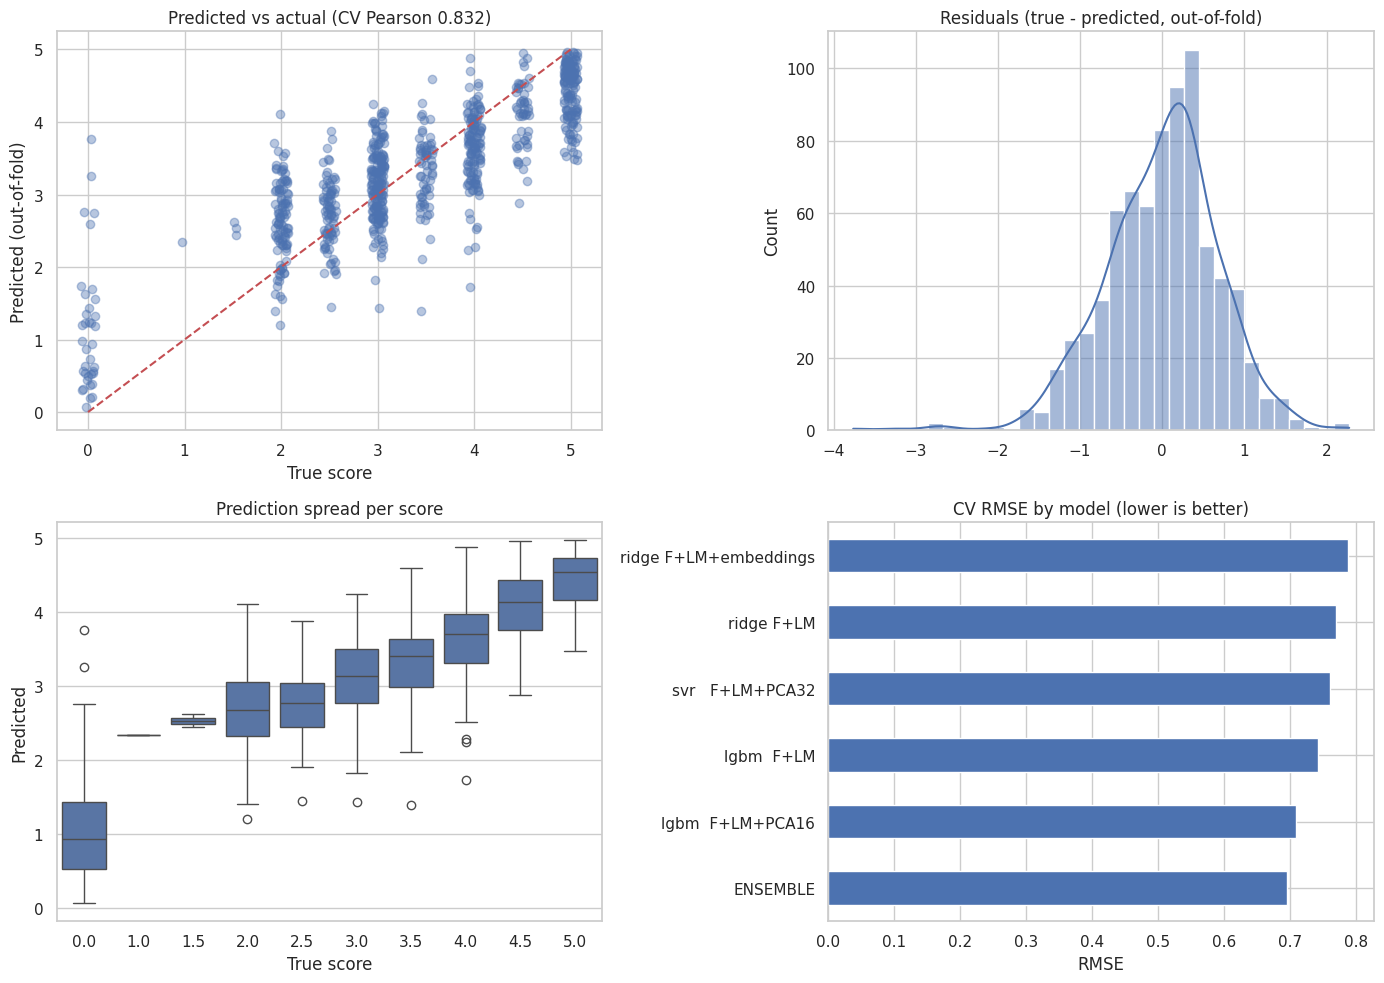

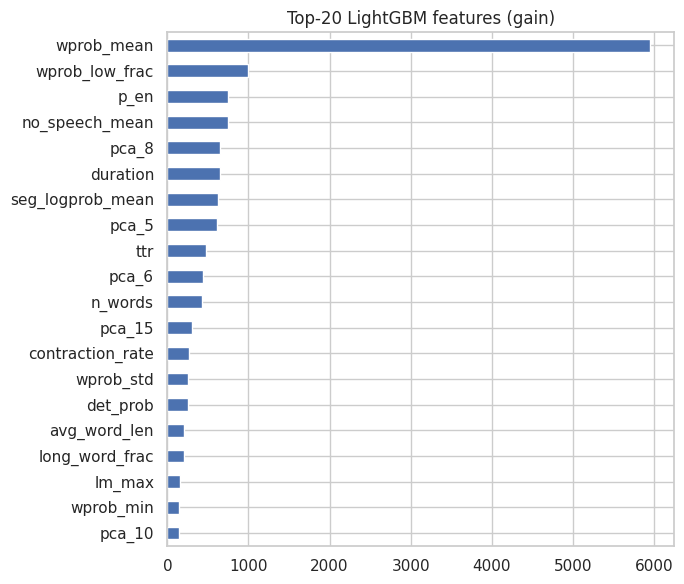

(216, 2) | predictions range 1.0556466905795225 - 4.955542751280501


,filename,label
0,audio_128.wav,3.134077
1,audio_156.wav,3.399072
2,audio_19.wav,4.201185
3,audio_108.wav,2.269734
4,audio_206.wav,2.621261


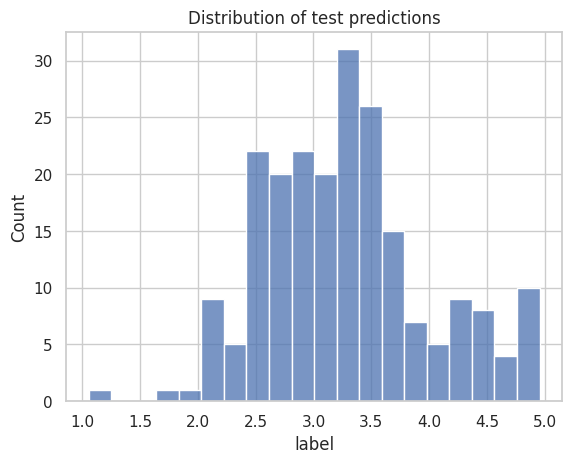

In [68]:
names = list(sets)[1:]                                    # the 5 models from Cell 11 (F-only reference excluded)
test_X = {
    "lgbm  F+LM":             FL_test.values,
    "lgbm  F+LM+PCA16":       np.hstack([FL_test.values, P_test[:, :16]]),
    "ridge F+LM":             FL_test.values,
    "ridge F+LM+embeddings":  np.hstack([FL_test.values, E_test]),
    "svr   F+LM+PCA32":       np.hstack([FL_test.values, P_test]),
}

# --- choose between the 5-model average and the 4-model average (without ridge+embeddings) ---
avg5 = np.clip(np.mean([oof11[n] for n in names], axis=0), 0, 5)
names4 = [n for n in names if n != "ridge F+LM+embeddings"]
avg4 = np.clip(np.mean([oof11[n] for n in names4], axis=0), 0, 5)
print(f"CV RMSE  5-model average: {rmse(y, avg5):.4f} | 4-model average: {rmse(y, avg4):.4f}")
final_names, oof_final = (names, avg5) if rmse(y, avg5) <= rmse(y, avg4) else (names4, avg4)
print("Final ensemble:", final_names)

# --- refit every chosen model on ALL training data; predict train (for training RMSE) and test ---
train_preds, test_preds = [], []
for n in final_names:
    mk, Xs = sets[n]
    m = mk().fit(Xs, y)
    train_preds.append(np.clip(m.predict(Xs), 0, 5))
    test_preds.append(np.clip(m.predict(test_X[n]), 0, 5))
train_final = np.clip(np.mean(train_preds, axis=0), 0, 5)
test_final  = np.clip(np.mean(test_preds,  axis=0), 0, 5)

# --- required metrics ---
print("\n================ FINAL RESULTS ================")
print(f"Baseline RMSE (predict mean)   : {rmse(y, np.full(len(y), y.mean())):.4f}")
print(f"TRAINING RMSE (in-sample)      : {rmse(y, train_final):.4f}   | Pearson {pearsonr(y, train_final)[0]:.4f}")
print(f"CROSS-VALIDATED RMSE (5-fold)  : {rmse(y, oof_final):.4f}   | Pearson {pearsonr(y, oof_final)[0]:.4f} | Spearman {spearmanr(y, oof_final)[0]:.4f}")
print("The training RMSE is optimistic (the models saw these labels); the cross-validated RMSE is the honest estimate.")

# --- plots ---
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
ax[0, 0].scatter(y + np.random.uniform(-.07, .07, len(y)), oof_final, alpha=.4); ax[0, 0].plot([0, 5], [0, 5], "r--")
ax[0, 0].set(xlabel="True score", ylabel="Predicted (out-of-fold)", title=f"Predicted vs actual (CV Pearson {pearsonr(y, oof_final)[0]:.3f})")
sns.histplot(y - oof_final, kde=True, ax=ax[0, 1]); ax[0, 1].set_title("Residuals (true - predicted, out-of-fold)")
sns.boxplot(x=np.round(y * 2) / 2, y=oof_final, ax=ax[1, 0]); ax[1, 0].set(xlabel="True score", ylabel="Predicted", title="Prediction spread per score")
cv_tbl = pd.Series({n: rmse(y, oof11[n]) for n in names} | {"ENSEMBLE": rmse(y, oof_final)}).sort_values()
cv_tbl.plot.barh(ax=ax[1, 1]); ax[1, 1].set_title("CV RMSE by model (lower is better)"); ax[1, 1].set_xlabel("RMSE")
plt.tight_layout(); plt.show()

# feature importance of the best single model
mk, Xs = sets["lgbm  F+LM+PCA16"]
gbm = mk().fit(Xs, y)
fn = list(FL_train.columns) + [f"pca_{i}" for i in range(16)]
pd.Series(gbm.booster_.feature_importance("gain"), index=fn).sort_values().tail(20).plot.barh(figsize=(7, 6), title="Top-20 LightGBM features (gain)")
plt.tight_layout(); plt.show()

# --- submission (the 216 rows of test.csv) ---
submission = pd.DataFrame({"filename": test_df.filename.values, "label": test_final})
submission.to_csv("/kaggle/working/submission.csv", index=False)
print(submission.shape, "| predictions range", submission.label.min(), "-", submission.label.max())
display(submission.head())
sns.histplot(submission.label, bins=20); plt.title("Distribution of test predictions"); plt.show()